In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('SPAM text message 20170820 - Data.csv')

In [3]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
le=LabelEncoder()

In [6]:
df['Category']=le.fit_transform(df['Category'])

In [7]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   int64 
 1   Message   5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5157 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5157 non-null   int64 
 1   Message   5157 non-null   object
dtypes: int64(1), object(1)
memory usage: 120.9+ KB


In [11]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [12]:
import matplotlib.pyplot as plt

In [13]:
x=df['Message']

In [14]:
y=df['Category']

In [15]:
x

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5157, dtype: object

In [16]:
y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: Category, Length: 5157, dtype: int64

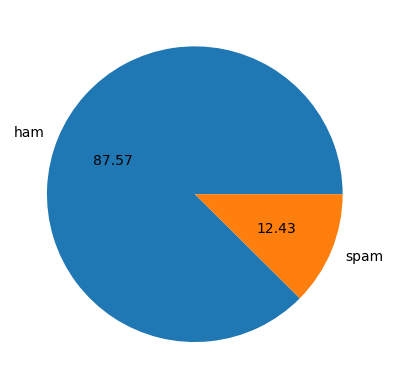

In [19]:
plt.pie(df['Category'].value_counts(), labels=['ham','spam'], autopct="%0.2f")
plt.show()

In [20]:
from sklearn.feature_extraction.text import CountVectorizer

In [25]:
c= CountVectorizer()

In [26]:
x=c.fit_transform(x)

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.20)

In [29]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()

In [30]:
model.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [31]:
y_pred= model.predict(x_test)

In [38]:
from sklearn.metrics import accuracy_score,classification_report

In [33]:
accuracy_score(y_test,y_pred)

0.9815891472868217

In [34]:
from sklearn.linear_model import LogisticRegression
X_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.20)

from sklearn.linear_model import LogisticRegression

model= LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(x_test)
print(y_pred)

[0 0 0 ... 0 0 0]


In [35]:
accuracy_score(y_test,y_pred)

0.9777131782945736

In [39]:
from sklearn.svm import SVC
s=SVC(class_weight='balanced')

s.fit(X_train,y_train)

y_pred=s.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9835271317829457
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.98      0.88      0.93       129

    accuracy                           0.98      1032
   macro avg       0.98      0.94      0.96      1032
weighted avg       0.98      0.98      0.98      1032



In [41]:
from sklearn.neighbors import KNeighborsClassifier
k= KNeighborsClassifier(n_neighbors=2)
k.fit(X_train,y_train)
y_p=k.predict(x_test)
print(accuracy_score(y_test,y_p))
print(classification_report(y_test,y_pred))

0.9292635658914729
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.98      0.88      0.93       129

    accuracy                           0.98      1032
   macro avg       0.98      0.94      0.96      1032
weighted avg       0.98      0.98      0.98      1032



In [43]:
from sklearn.tree import DecisionTreeClassifier
d=DecisionTreeClassifier()
d.fit(X_train,y_train)
y_d=d.predict(x_test)
print(accuracy_score(y_test,y_p))
print(classification_report(y_test,y_pred))

0.9292635658914729
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.98      0.88      0.93       129

    accuracy                           0.98      1032
   macro avg       0.98      0.94      0.96      1032
weighted avg       0.98      0.98      0.98      1032

